In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import contextily as ctx
import matplotlib.colors as colors
import numpy as np

In [ ]:
##### Load CSV file #####
df = pd.read_csv("./Non_Regulated_Lead_Samples.csv")
##### Clean up the data #####
df["Lead Amount (ppm)"] = df["Lead Amount (ppm)"].replace("<0.00005", "0.00001").astype(float)
#### Group by postal code and compute the average and standard deviation of lead level
df_avg = df.groupby("PartialPostalCode", as_index=False)["Lead Amount (ppm)"].median()
df_std = df.groupby("PartialPostalCode", as_index=False)["Lead Amount (ppm)"].std()
df_avg = pd.merge(df_avg, df_std, on="PartialPostalCode", suffixes=('_avg', '_std'))
# ##### Remove NaN values and Sort by postal code #####
df_avg.dropna(inplace=True)
df_avg = df_avg.sort_values(by='PartialPostalCode')

In [3]:
df_avg.describe()

,Lead Amount (ppm)_avg,Lead Amount (ppm)_std
count,95.000000,95.000000
mean,0.000199,0.034053
std,0.000277,0.111991
min,0.000010,0.000027
25%,0.000062,0.000568
50%,0.000085,0.002840
75%,0.000243,0.018679
max,0.002164,0.895753


In [4]:
##### Geocode postal codes to get latitude and longitude #####
column_names = ['Country code', 'PartialPostalCode', 'Place name', 'Admin name1', 'Admin code1', 'Admin name2', 'Admin code2', 'Admin name3', 'Admin code3', 'Latitude', 'Longitude', 'Accuracy']
postal_code_locations = pd.read_csv("./CA.txt", sep='\t', header=None, names=column_names)


In [5]:
postal_code_locations

,Country code,PartialPostalCode,Place name,Admin name1,Admin code1,Admin name2,Admin code2,Admin name3,Admin code3,Latitude,Longitude,Accuracy
0,CA,T0A,Eastern Alberta (St. Paul),Alberta,AB,NaN,NaN,NaN,NaN,54.7660,-111.7174,6.0
1,CA,T0B,Wainwright Region (Tofield),Alberta,AB,NaN,NaN,NaN,NaN,53.0727,-111.5816,6.0
2,CA,T0C,Central Alberta (Stettler),Alberta,AB,NaN,NaN,NaN,NaN,52.1431,-111.6941,5.0
3,CA,T0E,Western Alberta (Jasper),Alberta,AB,NaN,NaN,NaN,NaN,53.6758,-115.0948,5.0
4,CA,T0G,North Central Alberta (Slave Lake),Alberta,AB,NaN,NaN,NaN,NaN,55.6993,-114.4529,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1652,CA,S9V,Lloydminster,Saskatchewan,SK,NaN,NaN,NaN,NaN,53.2835,-110.0016,4.0
1653,CA,S9X,Meadow Lake,Saskatchewan,SK,NaN,NaN,NaN,NaN,54.1335,-108.4347,4.0
1654,CA,Y0A,Southeastern Yukon (Watson Lake),Yukon,YT,NaN,NaN,NaN,NaN,61.5793,-131.1481,6.0
1655,CA,Y0B,Central Yukon (Dawson City),Yukon,YT,NaN,NaN,NaN,NaN,64.6450,-137.5360,6.0


In [9]:
#### Merging the dataframes #####
columns_to_keep = ['PartialPostalCode', 'Latitude', 'Longitude', 'Place name']
df_final = pd.merge(df_avg, postal_code_locations[columns_to_keep], on='PartialPostalCode', how='left')

In [ ]:
##### Saving the cleaned data #####
df_final.to_csv('Lead_Sample_cleaned.csv', index=False)

In [8]:
# Create geometry column
geometry = [Point(xy) for xy in zip(df_final['Longitude'], df_final['Latitude'])]
gdf = gpd.GeoDataFrame(df_final, geometry=geometry, crs="EPSG:4326")  # WGS84


In [11]:
gdf

,PartialPostalCode,Lead Amount (ppm)_avg,Lead Amount (ppm)_std,Latitude,Longitude,Place name,geometry
0,M1B,0.000082,0.001698,43.8113,-79.1930,Scarborough (Malvern / Rouge River),POINT (-79.193 43.8113)
1,M1C,0.000061,0.003153,43.7878,-79.1564,Scarborough (Rouge Hill / Port Union / Highlan...,POINT (-79.1564 43.7878)
2,M1E,0.000066,0.000267,43.7678,-79.1866,Scarborough (Guildwood / Morningside / Ellesmere),POINT (-79.1866 43.7678)
3,M1G,0.000089,0.000434,43.7712,-79.2144,Scarborough (Woburn),POINT (-79.2144 43.7712)
4,M1H,0.000010,0.000183,43.7686,-79.2389,Scarborough (Cedarbrae),POINT (-79.2389 43.7686)
...,...,...,...,...,...,...,...
90,M9N,0.000085,0.006772,43.7068,-79.5170,Weston,POINT (-79.517 43.7068)
91,M9P,0.000074,0.000612,43.6949,-79.5323,Etobicoke (Westmount),POINT (-79.5323 43.6949)
92,M9R,0.000059,0.000198,43.6898,-79.5582,Etobicoke (Kingsview Village / St. Phillips / ...,POINT (-79.5582 43.6898)
93,M9V,0.000054,0.000552,43.7432,-79.5876,Etobicoke (South Steeles / Silverstone / Humbe...,POINT (-79.5876 43.7432)


In [12]:
gdf = gdf.dropna(subset=['geometry'])
gdf = gdf.set_crs(epsg=4326, inplace=False)  
gdf_webmerc = gdf.to_crs(epsg=3857)

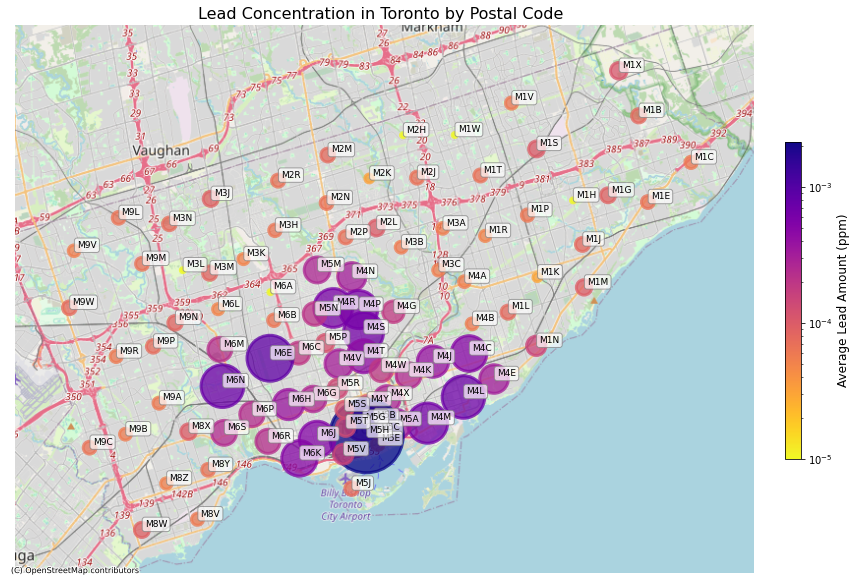

In [18]:
column_name = "Lead Amount (ppm)_avg"
error_name = "Lead Amount (ppm)_std"
colorscheme = "plasma_r"

# Create a figure with a specific size
fig, ax = plt.subplots(figsize=(12, 10))

# Create a log-normalized colormap for the lead amounts
# This helps visualize values that span different orders of magnitude
norm = colors.LogNorm(vmin=df_final[column_name].min(), vmax=df_final[column_name].max())

# Plot the GeoDataFrame with points colored by lead amount and sized accordingly
scatter = gdf_webmerc.plot(
    ax=ax,
    column=column_name,
    cmap=colorscheme,  
    norm=norm,
    linewidth=3,
    markersize=gdf_webmerc[column_name] * 2500000,  # Scale the points based on lead amount
    alpha=0.75,  
    legend=False  
)

# Add OpenStreetMap basemap
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title('Lead Concentration in Toronto by Postal Code', fontsize=16)
ax.set_axis_off()  # Remove axis

# Add a colorbar
sm = plt.cm.ScalarMappable(cmap=colorscheme, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.04)
cbar.set_label("Average Lead Amount (ppm)", fontsize=12)

# Add labels to the points
for idx, row in gdf_webmerc.iterrows():
    ax.annotate(
        text=row['PartialPostalCode'],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(3, 3),  # Offset
        textcoords="offset points",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
    )

# Set the extent to cover all points with some padding
x_padding = (gdf_webmerc.total_bounds[2] - gdf_webmerc.total_bounds[0]) * 0.1
y_padding = (gdf_webmerc.total_bounds[3] - gdf_webmerc.total_bounds[1]) * 0.1
ax.set_xlim(gdf_webmerc.total_bounds[0] - x_padding, gdf_webmerc.total_bounds[2] + x_padding)
ax.set_ylim(gdf_webmerc.total_bounds[1] - y_padding, gdf_webmerc.total_bounds[3] + y_padding)

plt.tight_layout()

plt.savefig("Lead_Concentration_Toronto_python.png", bbox_inches='tight', dpi=600)


# plt.show()